In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from mahotas.features import surf as SURF
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
DATA = "data"
PATH = os.path.abspath('')
SAMPLES = os.listdir(f'{PATH}/{DATA}')

SIFT = cv2.SIFT_create(nfeatures=100)
HOG = cv2.HOGDescriptor()

In [3]:
def get_descriptors(sample, tech):
    images = os.listdir(f"{PATH}/{DATA}/{sample}")
    images = [f"{PATH}/{DATA}/{sample}/{name}" for name in images]
    descriptors = []
    
    for n, img in enumerate(images):
        img_rgb = cv2.imread(img)
        if tech == 'sift':
            img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
            kps, des = SIFT.detectAndCompute(img_gray, None)
            if des is not None:  
                des = np.mean(des, axis=0)
        elif tech == 'surf':
            img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
            des = SURF.surf(img_gray)
            if des is not None:  
                des = np.mean(des, axis=0)
        elif tech == 'hog':
            img_rgb = cv2.resize(img_rgb, (128, 128))
            img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
            des = HOG.compute(img_gray)
        
        if des is not None:  
            descriptors.append(des)
    
    return descriptors


In [4]:
Data = {'sift': {}, 'surf': {}, 'hog': {}}


In [5]:
for model in Data:
    data = []

    for sample in SAMPLES:
        desc = get_descriptors(sample, model)
        data += desc

    Data[model] = np.array(data)
    
    print(f"Data extracted successfully for {model.upper()}, total descriptors: {len(Data[model])}")


Data extracted successfully for SIFT, total descriptors: 312


C:\Program Files\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Program Files\Python311\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Data extracted successfully for SURF, total descriptors: 314
Data extracted successfully for HOG, total descriptors: 314


In [6]:

labels = np.zeros(312)
labels[0:156] = 0
labels[156:312] = 1


for model in ['surf', 'hog']:
    Data[model] = Data[model][:312]  


In [7]:
imputer = SimpleImputer(strategy='mean')

In [8]:
DataSet = {'sift': {}, 'surf': {}, 'hog': {}}

In [9]:
for model in Data:
    Data[model] = imputer.fit_transform(Data[model])  
    DataSet[model]['x_train'], DataSet[model]['x_test'], DataSet[model]['y_train'], DataSet[model]['y_test'] = train_test_split(Data[model], labels, test_size=0.3)

In [10]:
for model in DataSet:
    DataSet[model]['x_train'] = imputer.fit_transform(DataSet[model]['x_train'])
    DataSet[model]['x_test'] = imputer.transform(DataSet[model]['x_test'])  

In [11]:
# Initializing the models

Models = {'sift': {}, 'surf': {}, 'hog': {}}

for model in Models:
    Models[model]['RFC'] = RandomForestClassifier(n_estimators=500)
    Models[model]['ANN'] = MLPClassifier(hidden_layer_sizes=(100,), activation='logistic', max_iter=1000)


In [12]:
# Training RandomForestClassifiers

for model in Models:
    Models[model]['RFC'].fit(DataSet[model]['x_train'], DataSet[model]['y_train'])

In [13]:
# Training ANNs

for model in Models:
    Models[model]['ANN'].fit(DataSet[model]['x_train'], DataSet[model]['y_train'])

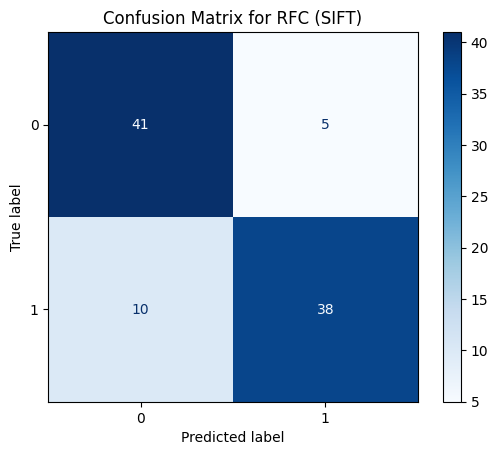

Classification Report for RFC (SIFT):
               precision    recall  f1-score   support

         0.0       0.80      0.89      0.85        46
         1.0       0.88      0.79      0.84        48

    accuracy                           0.84        94
   macro avg       0.84      0.84      0.84        94
weighted avg       0.84      0.84      0.84        94



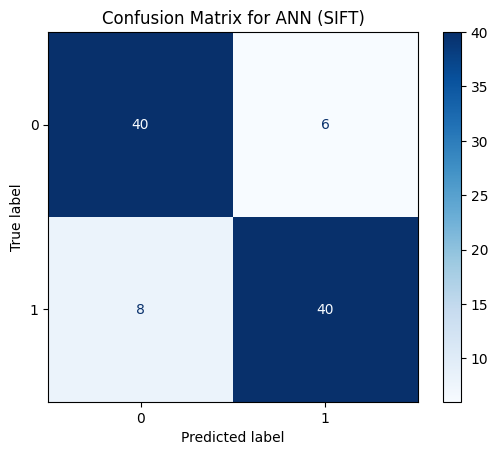

Classification Report for ANN (SIFT):
               precision    recall  f1-score   support

         0.0       0.83      0.87      0.85        46
         1.0       0.87      0.83      0.85        48

    accuracy                           0.85        94
   macro avg       0.85      0.85      0.85        94
weighted avg       0.85      0.85      0.85        94




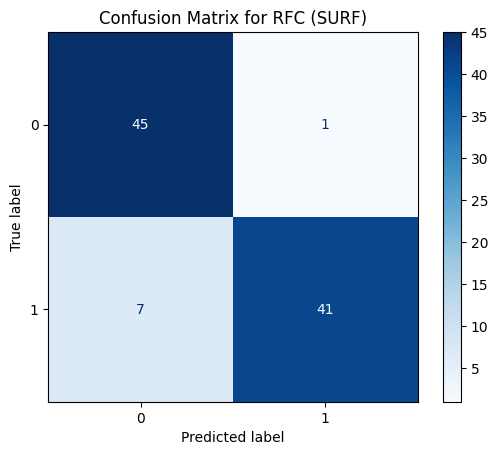

Classification Report for RFC (SURF):
               precision    recall  f1-score   support

         0.0       0.87      0.98      0.92        46
         1.0       0.98      0.85      0.91        48

    accuracy                           0.91        94
   macro avg       0.92      0.92      0.91        94
weighted avg       0.92      0.91      0.91        94



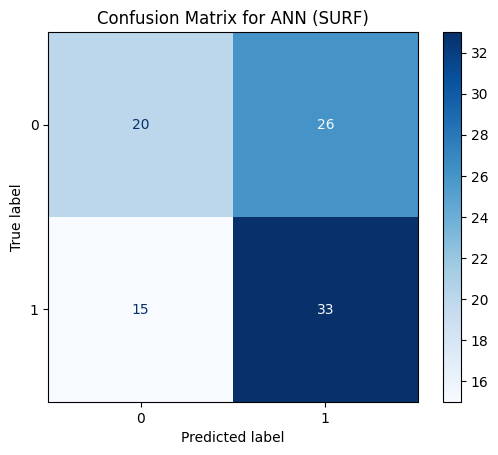

Classification Report for ANN (SURF):
               precision    recall  f1-score   support

         0.0       0.57      0.43      0.49        46
         1.0       0.56      0.69      0.62        48

    accuracy                           0.56        94
   macro avg       0.57      0.56      0.56        94
weighted avg       0.57      0.56      0.56        94




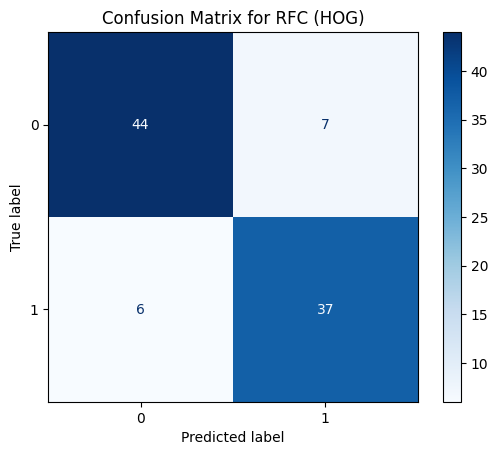

Classification Report for RFC (HOG):
               precision    recall  f1-score   support

         0.0       0.88      0.86      0.87        51
         1.0       0.84      0.86      0.85        43

    accuracy                           0.86        94
   macro avg       0.86      0.86      0.86        94
weighted avg       0.86      0.86      0.86        94



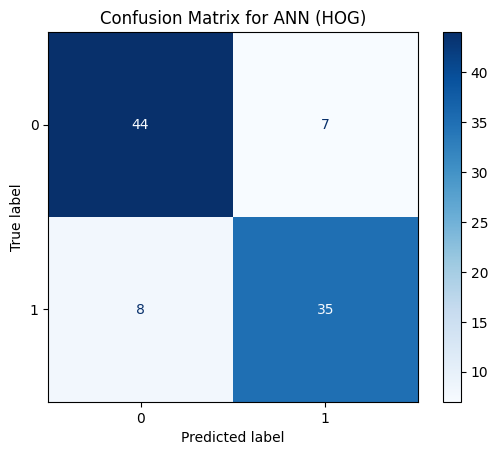

Classification Report for ANN (HOG):
               precision    recall  f1-score   support

         0.0       0.85      0.86      0.85        51
         1.0       0.83      0.81      0.82        43

    accuracy                           0.84        94
   macro avg       0.84      0.84      0.84        94
weighted avg       0.84      0.84      0.84        94




In [16]:
for model in Models:
    for i in Models[model]:
        pred = Models[model][i].predict(DataSet[model]['x_test'])
        cm = confusion_matrix(DataSet[model]['y_test'], pred)
        report = classification_report(DataSet[model]['y_test'], pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix for {i.upper()} ({model.upper()})')
        plt.show()
        print(f"Classification Report for {i} ({model.upper()}):\n", report)
    print()